# Visualize Principal Movements from PCA 

## Load preprocessed keypoints and build PCA Matrix

In [22]:
from pathlib import Path
import numpy as np
import pandas as pd

N_KEYPOINTS = 38

# Path to the canonicalised, filtered, NOT z-scored file you just created
PREPROC_PATH = Path(
    "/Users/cartersale/Documents/Pose_Dynamics/projects/mirror_game/data/preprocessed/mirror_game_preprocessed.csv"
)

df = pd.read_csv(PREPROC_PATH)
print(f"Loaded preprocessed dataset: {PREPROC_PATH}")
print("Shape:", df.shape)

# Pose columns: x0,y0,z0,...,x37,y37,z37
XYZ_COLS = [f"{axis}{k}" for k in range(N_KEYPOINTS) for axis in ("x", "y", "z")]

missing = [c for c in XYZ_COLS if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected pose columns: {missing[:10]}")

# Build PCA matrix (frames × 114)
X = df[XYZ_COLS].to_numpy(dtype=float)
print("PCA matrix X shape:", X.shape)


Loaded preprocessed dataset: /Users/cartersale/Documents/Pose_Dynamics/projects/mirror_game/data/preprocessed/mirror_game_preprocessed.csv
Shape: (455138, 124)
PCA matrix X shape: (455138, 114)


## Explained Variance (Scree Plot)

/opt/anaconda3/envs/matb-analysis/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/matb-analysis/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/matb-analysis/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/matb-analysis/lib/python3.12/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/anaconda3/envs/matb-analysis/lib/python3.12/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/anaconda3/envs/matb-analysis/lib/python3.12/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value enc

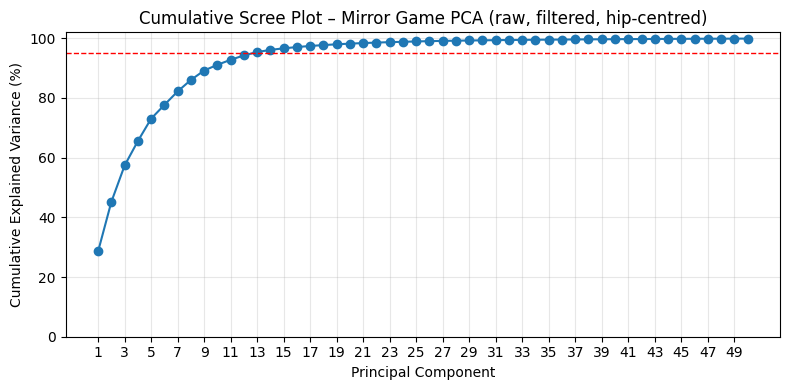

PCs needed for ≥95% variance: 13


In [23]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_mean = X.mean(axis=0, keepdims=True)
X_mc   = X - X_mean

N_COMPONENTS = min(50, X_mc.shape[1])

pca = PCA(n_components=N_COMPONENTS)
X_scores = pca.fit_transform(X_mc)

expl_var = pca.explained_variance_ratio_ * 100.0
cum_expl = np.cumsum(expl_var)
pcs = np.arange(1, N_COMPONENTS + 1)

plt.figure(figsize=(8, 4))
plt.plot(pcs, cum_expl, marker="o")
plt.axhline(95, linestyle="--", color="r", linewidth=1)
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Cumulative Scree Plot – Mirror Game PCA (raw, filtered, hip-centred)")
plt.grid(alpha=0.3)
plt.xticks(pcs[::2])
plt.ylim(0, 102)
plt.tight_layout()
plt.show()

k95 = np.argmax(cum_expl >= 95) + 1
print(f"PCs needed for ≥95% variance: {k95}")


## Visualize Principal Movements

### Front View

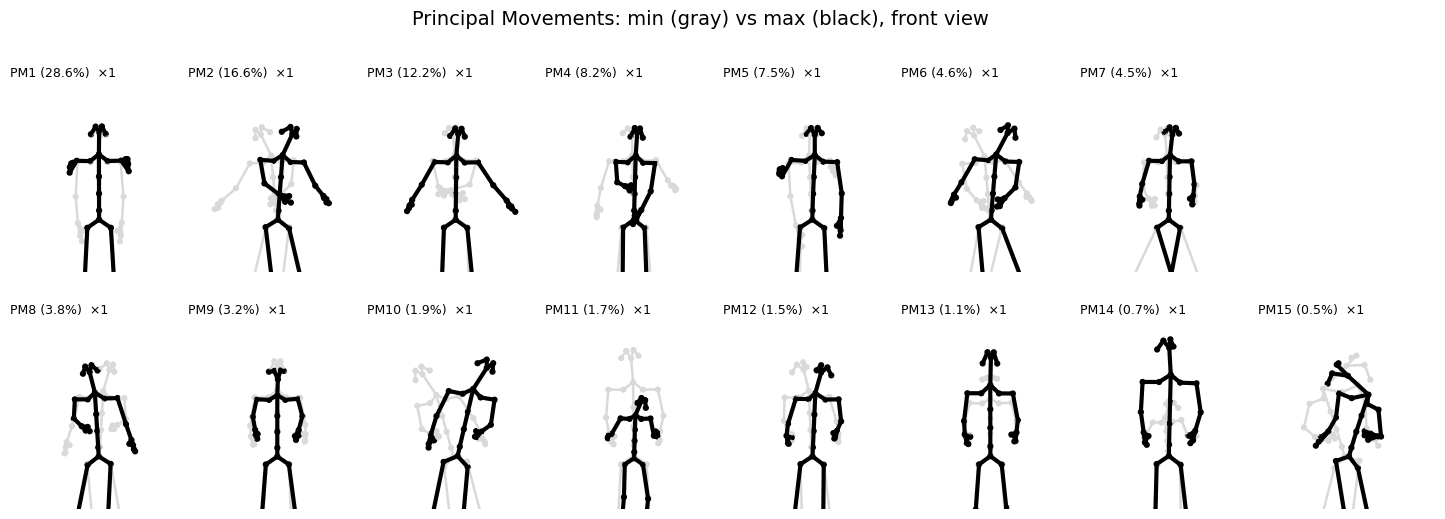

Saved front-view PM figure to: /Users/cartersale/Documents/Pose_Dynamics/projects/mirror_game/results/figures/principal_movements_minmax_front_var.svg


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from pose_dynamics.projects.mirror_game.pipeline import SKELETON_EDGES

OUT_DIR = Path("/Users/cartersale/Documents/Pose_Dynamics/projects/mirror_game/results/figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

edges = SKELETON_EDGES
n_points = N_KEYPOINTS

def pose_from_pc(score, pc_idx, X_mean, pca, n_points):
    comp = pca.components_[pc_idx]          # (114,)
    pose_vec = X_mean.ravel() + score * comp
    return pose_vec.reshape(n_points, 3)

def project(P, view="front"):
    if view == "front":
        return P[:, [0, 1]]
    elif view == "side":
        return P[:, [2, 1]]
    else:
        raise ValueError("view must be 'front' or 'side'")

def draw_skeleton(ax, P2, edges, color, lw=2.0, alpha=1.0):
    for i, j in edges:
        ax.plot(
            [P2[i,0], P2[j,0]],
            [P2[i,1], P2[j,1]],
            color=color,
            lw=lw,
            alpha=alpha
        )
    ax.scatter(
        P2[:,0], P2[:,1],
        s=20,
        color=color,
        alpha=alpha,
        edgecolors="none",
    )

def overlay_min_max_front(ax, Pmin, Pmax, edges):
    Pf_min = project(Pmin, "front")
    Pf_max = project(Pmax, "front")
    draw_skeleton(ax, Pf_min, edges, color="0.85", lw=1.8, alpha=1.0)  # gray
    draw_skeleton(ax, Pf_max, edges, color="0.00", lw=3.0,  alpha=1.0)  # black
    ax.set_aspect("equal")
    ax.axis("off")

def rms_displacement(Pmin, Pmax):
    D = np.linalg.norm(Pmax - Pmin, axis=1)
    return np.sqrt((D**2).mean())

# global score range per PC
scores_all = X_scores
pc_mins = scores_all.min(axis=0)
pc_maxs = scores_all.max(axis=0)

TARGET_RMS = 0.25  # tune if you want bigger/smaller swings
amp_factors = []

for pc in range(pca.n_components_):
    Pmin_raw = pose_from_pc(pc_mins[pc], pc, X_mean, pca, n_points)
    Pmax_raw = pose_from_pc(pc_maxs[pc], pc, X_mean, pca, n_points)
    base_rms = rms_displacement(Pmin_raw, Pmax_raw)

    if base_rms <= 1e-12:
        amp = 1.0
    else:
        amp = TARGET_RMS / base_rms

    if amp < 1.25:   label = "×1"
    elif amp < 1.75: label = "×1.5"
    elif amp < 2.5:  label = "×2"
    elif amp < 3.5:  label = "×3"
    else:            label = f"×{amp:.1f}"

    amp_factors.append((amp, label))

# explained variance (%)
expl_var = pca.explained_variance_ratio_ * 100.0

# plot first 15 PMs, layout 7 + 8
N = min(15, pca.n_components_)
layout = [7, 8]
total_cols = max(layout)
nrows = len(layout)

fig = plt.figure(figsize=(total_cols * 2.3, nrows * 3.0))
fig.suptitle("Principal Movements: min (gray) vs max (black), front view", fontsize=14, y=0.97)

pc_idx = 0
for r, ncols in enumerate(layout):
    for c in range(ncols):
        if pc_idx >= N:
            break

        amp, amp_label = amp_factors[pc_idx]
        mu   = X_mean.ravel()
        comp = pca.components_[pc_idx]

        Pmin = (mu + amp * pc_mins[pc_idx] * comp).reshape(n_points, 3)
        Pmax = (mu + amp * pc_maxs[pc_idx] * comp).reshape(n_points, 3)

        ax = plt.subplot2grid((nrows, total_cols), (r, c))
        overlay_min_max_front(ax, Pmin, Pmax, edges)
        ax.set_title(
            f"PM{pc_idx+1} ({expl_var[pc_idx]:.1f}%)  {amp_label}",
            fontsize=9,
            loc="left",
            pad=1,
        )
        ax.set_xlim(-0.6, 0.6)
        ax.set_ylim(-0.3, 1.0)

        pc_idx += 1

plt.subplots_adjust(wspace=0.0002, hspace=0.05)
fig_path_front = OUT_DIR / "principal_movements_minmax_front_var.svg"
plt.savefig(fig_path_front, dpi=300)
plt.show()

print(f"Saved front-view PM figure to: {fig_path_front}")


### Side-view

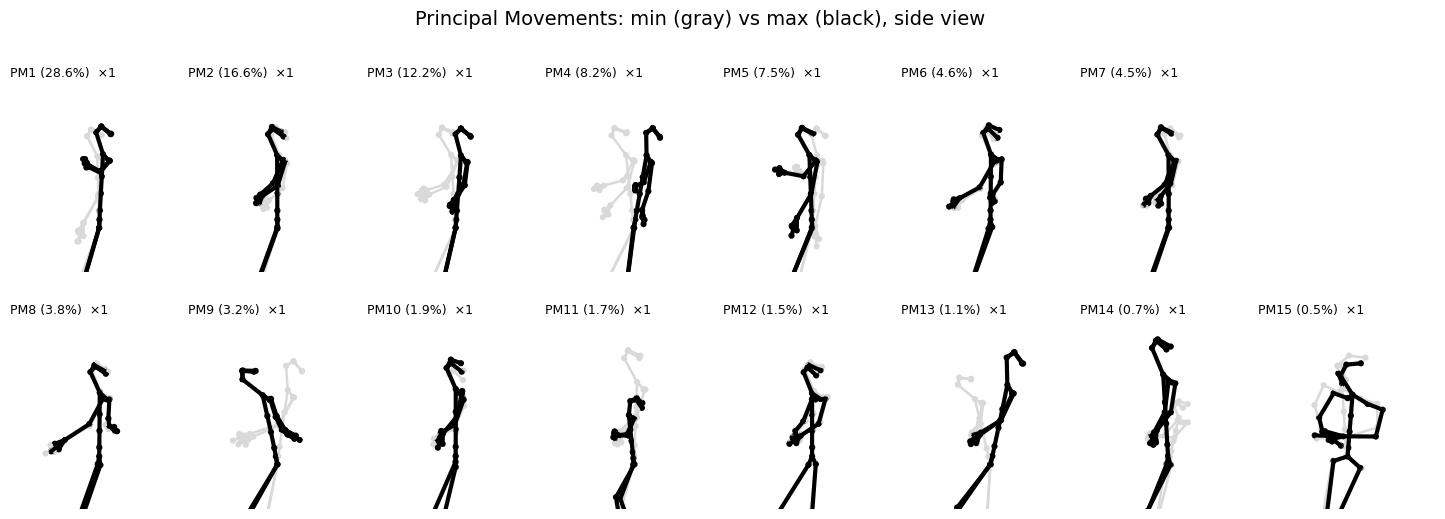

Saved side-view PM figure to: /Users/cartersale/Documents/Pose_Dynamics/projects/mirror_game/results/figures/principal_movements_minmax_side_var.svg


In [29]:
def overlay_min_max_side(ax, Pmin, Pmax, edges):
    Ps_min = project(Pmin, "side")
    Ps_max = project(Pmax, "side")
    draw_skeleton(ax, Ps_min, edges, color="0.85", lw=1.8, alpha=1.0)
    draw_skeleton(ax, Ps_max, edges, color="0.00", lw=3.0,  alpha=1.0)
    ax.set_aspect("equal")
    ax.axis("off")

N = min(15, pca.n_components_)
layout = [7, 8]
total_cols = max(layout)
nrows = len(layout)

fig = plt.figure(figsize=(total_cols * 2.3, nrows * 3.0))
fig.suptitle("Principal Movements: min (gray) vs max (black), side view", fontsize=14, y=0.97)

pc_idx = 0
for r, ncols in enumerate(layout):
    for c in range(ncols):
        if pc_idx >= N:
            break

        amp, amp_label = amp_factors[pc_idx]
        mu   = X_mean.ravel()
        comp = pca.components_[pc_idx]

        Pmin = (mu + amp * pc_mins[pc_idx] * comp).reshape(n_points, 3)
        Pmax = (mu + amp * pc_maxs[pc_idx] * comp).reshape(n_points, 3)

        ax = plt.subplot2grid((nrows, total_cols), (r, c))
        overlay_min_max_side(ax, Pmin, Pmax, edges)
        ax.set_title(
            f"PM{pc_idx+1} ({expl_var[pc_idx]:.1f}%)  {amp_label}",
            fontsize=9,
            loc="left",
            pad=1,
        )
        ax.set_xlim(-0.6, 0.6)
        ax.set_ylim(-0.3, 1.0)

        pc_idx += 1

plt.subplots_adjust(wspace=0.0002, hspace=0.05)
fig_path_side = OUT_DIR / "principal_movements_minmax_side_var.svg"
plt.savefig(fig_path_side, dpi=300)
plt.show()

print(f"Saved side-view PM figure to: {fig_path_side}")


### Animation

In [30]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

N_ANIM = min(8, pca.n_components_)
ROWS, COLS = 2, 4
assert ROWS * COLS >= N_ANIM

frames = 120
thetas = np.linspace(0, 2 * np.pi, frames)

fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS * 3, ROWS * 4))
axes = axes.flatten()

# Prepare artists: for each PC, we keep line segments + scatter
line_artists = []
scatter_artists = []

for i in range(N_ANIM):
    ax = axes[i]
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_xlim(-0.6, 0.6)
    ax.set_ylim(-0.3, 1.0)
    ax.set_title(f"PM{i+1} ({expl_var[i]:.1f}%)", fontsize=10)

    # dummy initial pose = mean
    P0 = X_mean.ravel().reshape(n_points, 3)
    Pf0 = project(P0, "front")

    # line segments
    pc_lines = []
    for (a, b) in edges:
        line, = ax.plot(
            [Pf0[a,0], Pf0[b,0]],
            [Pf0[a,1], Pf0[b,1]],
            color="k",
            lw=2.0,
        )
        pc_lines.append(line)

    # scatter
    scat = ax.scatter(
        Pf0[:,0], Pf0[:,1],
        s=20,
        color="k",
        edgecolors="none"
    )

    line_artists.append(pc_lines)
    scatter_artists.append(scat)

# hide unused axes
for j in range(N_ANIM, len(axes)):
    axes[j].axis("off")

plt.tight_layout()

def update(frame_idx):
    theta = thetas[frame_idx]

    for pc_idx in range(N_ANIM):
        amp, amp_label = amp_factors[pc_idx]
        comp = pca.components_[pc_idx]

        # oscillate score in a symmetric range based on observed min/max
        score_range = 0.5 * (pc_maxs[pc_idx] - pc_mins[pc_idx])
        score = amp * score_range * np.sin(theta)

        P = (X_mean.ravel() + score * comp).reshape(n_points, 3)
        Pf = project(P, "front")

        # update lines
        for line, (a, b) in zip(line_artists[pc_idx], edges):
            line.set_data(
                [Pf[a,0], Pf[b,0]],
                [Pf[a,1], Pf[b,1]],
            )

        # update scatter
        scatter_artists[pc_idx].set_offsets(Pf[:, :2])

    return [artist for sub in line_artists for artist in sub] + scatter_artists

anim = animation.FuncAnimation(
    fig,
    update,
    frames=frames,
    interval=40,
    blit=True,
)

anim_path = OUT_DIR / "principal_movements_front_animation.mp4"
anim.save(anim_path, fps=25, dpi=150)
plt.close(fig)

print(f"Saved PM animation to: {anim_path}")


Saved PM animation to: /Users/cartersale/Documents/Pose_Dynamics/projects/mirror_game/results/figures/principal_movements_front_animation.mp4
